# Load the Data



In [22]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv("PowerPlant/powerplant_data.csv")

In [26]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [28]:
# AT =Temperature
# V = Vacuum
# AP = Pressure
# RH = Humidity
# PE =Produced Energy



In [30]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [32]:
x = df.drop("PE", axis =1)
y = df["PE"]


In [34]:
x.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [44]:
#Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( x, y, test_size = 0.2, random_state =42)

In [46]:
df.shape

(9568, 5)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Convert data into tensors

In [ ]:
import torch
import torch.nn as nn

# data --> tensors

In [63]:

x_train_tensor = torch.tensor(x_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

x_test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [65]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [69]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle =True)
test_loader = DataLoader(test_dataset, batch_size = 32, )

# Define ANN Model

In [140]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [142]:
import torch.optim as optim

model = ANN()

#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train ANN Model

In [182]:
# Training the model
train_loss = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0         # total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 Batch
        # yb = labels of 1 Batch
        
        optimizer.zero_grad()
        
        outputs = model(xb)   # forward propagation step
        loss = criterion(outputs, yb)   # compute loss
        loss.backward()       # back propagation... compute gradients
        optimizer.step()      # parameters update

        running_loss += loss.item()   # loss is a tensor

    epoch_train_loss = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)

    # Validating the model
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():     # no gradients to compute
        
        for xb, yb in test_loader:
            outputs = model(xb)   # forward propagation step
            loss = criterion(outputs, yb)   # compute loss
            running_val_loss += loss.item()
     
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss:.4f} & val loss = {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 20.4973 & val loss = 18.5095
epoch 2/100 ==> train loss = 20.5655 & val loss = 19.2222
epoch 3/100 ==> train loss = 20.4596 & val loss = 21.1701
epoch 4/100 ==> train loss = 20.5718 & val loss = 19.9473
epoch 5/100 ==> train loss = 20.5630 & val loss = 18.9367
epoch 6/100 ==> train loss = 20.6585 & val loss = 18.4939
epoch 7/100 ==> train loss = 20.5994 & val loss = 18.8827
epoch 8/100 ==> train loss = 20.6038 & val loss = 19.1378
epoch 9/100 ==> train loss = 20.5906 & val loss = 18.8998
epoch 10/100 ==> train loss = 20.5382 & val loss = 18.7491
epoch 11/100 ==> train loss = 20.4943 & val loss = 19.2909
epoch 12/100 ==> train loss = 20.4537 & val loss = 18.5358
epoch 13/100 ==> train loss = 20.5050 & val loss = 18.5977
epoch 14/100 ==> train loss = 20.4061 & val loss = 19.0493
epoch 15/100 ==> train loss = 20.5176 & val loss = 19.8720
epoch 16/100 ==> train loss = 20.5824 & val loss = 19.1351
epoch 17/100 ==> train loss = 20.6394 & val loss = 18.5952
epoch 

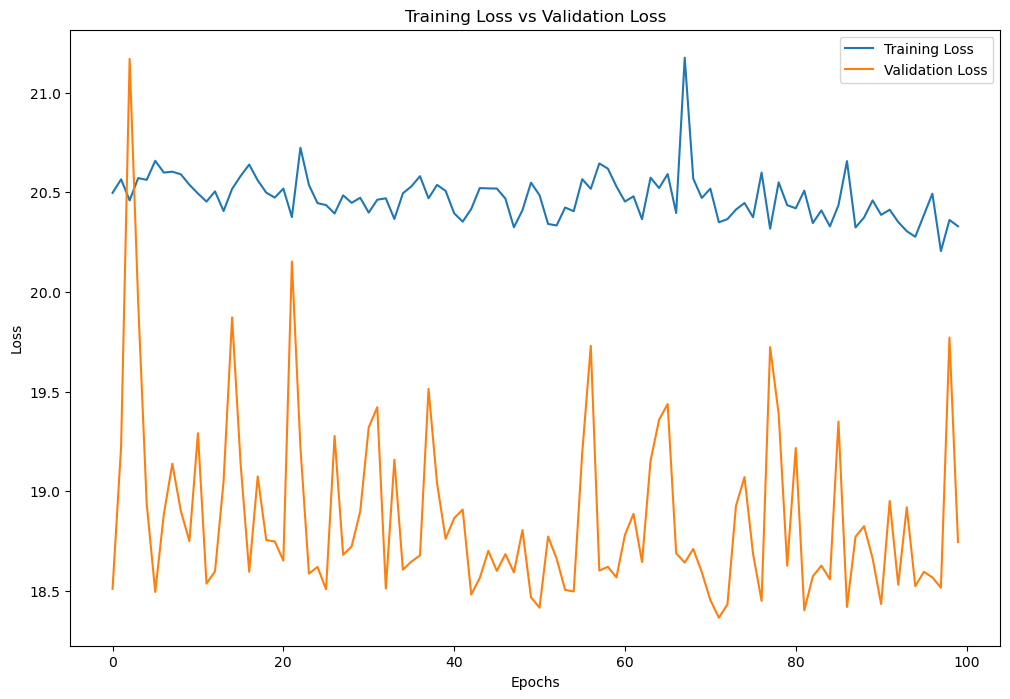

In [183]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame({
    "Training Loss": train_loss,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12, 8))

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")

plt.legend()
plt.show()

# Loading the model

In [185]:
model.load_state_dict(torch.load("PowerPlant/best_model.pt"))

<All keys matched successfully>

# Evaluate the Model

In [197]:
model.eval()

with torch.no_grad():

    # Predictions
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    # MSE Loss
    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.314300537109375
Testing MSE: 18.48453140258789


In [201]:
from sklearn.metrics import r2_score

print("r2 Score = ", r2_score(y_test,test_preds) )

r2 Score =  0.9354013323542711


In [207]:
# Compare the Values
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1 )

,Predicted Values,Actual Values
0,434.551514,433.27
1,436.515717,438.16
2,461.308136,458.42
3,476.508606,480.82
4,434.919891,441.41
...,...,...
1909,450.978363,456.70
1910,431.047638,438.04
1911,467.258698,467.80
1912,430.530304,437.14
